In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
zip_path = "/content/drive/MyDrive/archive.zip"

extract_path = "/content/drive/MyDrive/product-classification/"

In [3]:
import zipfile

zip_path = "/content/drive/MyDrive/archive.zip"

local_extract_path = "/content/fashion-data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(local_extract_path)

print("Extraction completed")

Extraction completed


In [4]:
import os

print(os.listdir(local_extract_path))

['styles.csv', 'myntradataset', 'images']


In [5]:
import shutil
import os

myntra_path = "/content/fashion-data/myntradataset"

if os.path.exists(myntra_path):
    shutil.rmtree(myntra_path)
    print("myntradataset removed")
else:
    print("Folder not found")

myntradataset removed


In [6]:
print(os.listdir("/content/fashion-data"))

['styles.csv', 'images']


In [7]:
!pip install torch torchvision timm pandas scikit-learn pillow

In [8]:
import pandas as pd

csv_path = "/content/fashion-data/styles.csv"

df = pd.read_csv(csv_path, on_bad_lines='skip')
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [9]:
df['subCategory'].value_counts()

,count
subCategory,
Topwear,15402
Shoes,7343
Bags,3055
Bottomwear,2694
Watches,2542
Innerwear,1808
Jewellery,1079
Eyewear,1073
Fragrance,1011


In [10]:
df['articleType'].value_counts()

,count
articleType,
Tshirts,7067
Shirts,3217
Casual Shoes,2845
Watches,2542
Sports Shoes,2036
...,...
Cushion Covers,1
Mens Grooming Kit,1
Body Wash and Scrub,1


In [11]:
target_classes = {
    'Tshirts': 'tshirts',
    'Shirts': 'shirts',
    'Casual Shoes': 'shoes',
    'Sports Shoes': 'shoes',
    'Watches': 'watches',
    'Handbags': 'bags'
}

filtered_df = df[df['articleType'].isin(target_classes.keys())].copy()

filtered_df['label'] = filtered_df['articleType'].map(target_classes)

filtered_df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,label
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,shirts
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,watches
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,tshirts
5,1855,Men,Apparel,Topwear,Tshirts,Grey,Summer,2011.0,Casual,Inkfruit Mens Chain Reaction T-shirt,tshirts
6,30805,Men,Apparel,Topwear,Shirts,Green,Summer,2012.0,Ethnic,Fabindia Men Striped Green Shirt,shirts


In [12]:
filtered_df['label'].value_counts()

,count
label,
tshirts,7067
shoes,4881
shirts,3217
watches,2542
bags,1759


In [13]:
import os

image_dir = "/content/fashion-data/images"

filtered_df['image_path'] = filtered_df['id'].astype(str).apply(
    lambda x: os.path.join(image_dir, x + ".jpg")
)

In [14]:
filtered_df = filtered_df[
    filtered_df['image_path'].apply(os.path.exists)
]

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

filtered_df['label_encoded'] = le.fit_transform(filtered_df['label'])

print(le.classes_)

['bags' 'shirts' 'shoes' 'tshirts' 'watches']


In [16]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    filtered_df,
    test_size=0.2,
    stratify=filtered_df['label_encoded'],
    random_state=42
)

In [17]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class ProductDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.df.iloc[idx]['image_path']
        label = self.df.iloc[idx]['label_encoded']

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [18]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [19]:
from torch.utils.data import DataLoader

train_dataset = ProductDataset(train_df, train_transform)
val_dataset = ProductDataset(val_df, val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [20]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = resnet18(weights=ResNet18_Weights.DEFAULT)

model.fc = nn.Linear(model.fc.in_features, 5)

model = model.to(device)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 159MB/s]


In [32]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [33]:
def calculate_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correct = (preds == labels).sum().item()
    return correct / labels.size(0)

In [34]:
epochs = 5

for epoch in range(epochs):

    model.train()

    train_loss = 0
    train_acc = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        train_acc += calculate_accuracy(outputs, labels)

    model.eval()

    val_loss = 0
    val_acc = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            val_acc += calculate_accuracy(outputs, labels)

    print(f"\nEpoch {epoch+1}/{epochs}")

    print(f"Train Loss: {train_loss/len(train_loader):.4f}")
    print(f"Train Accuracy: {train_acc/len(train_loader):.4f}")

    print(f"Validation Loss: {val_loss/len(val_loader):.4f}")
    print(f"Validation Accuracy: {val_acc/len(val_loader):.4f}")


Epoch 1/5
Train Loss: 0.1689
Train Accuracy: 0.9571
Validation Loss: 0.0403
Validation Accuracy: 0.9895

Epoch 2/5
Train Loss: 0.0488
Train Accuracy: 0.9863
Validation Loss: 0.0224
Validation Accuracy: 0.9921

Epoch 3/5
Train Loss: 0.0304
Train Accuracy: 0.9902
Validation Loss: 0.0212
Validation Accuracy: 0.9939

Epoch 4/5
Train Loss: 0.0293
Train Accuracy: 0.9917
Validation Loss: 0.0432
Validation Accuracy: 0.9851

Epoch 5/5
Train Loss: 0.0287
Train Accuracy: 0.9922
Validation Loss: 0.0202
Validation Accuracy: 0.9962


In [36]:
torch.save(model.state_dict(), "efficientnet_product_classifier.pth")

In [22]:
from PIL import Image
import matplotlib.pyplot as plt

class_names = ['bags', 'shirts', 'shoes', 'tshirts', 'watches']

image_path = "/content/fashion-data/images/47957.jpg"

image = Image.open(image_path).convert("RGB")

input_image = val_transform(image).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    outputs = model(input_image)

    _, pred = torch.max(outputs, 1)

predicted_class = class_names[pred.item()]

print("Prediction:", predicted_class)


Prediction: shirts


In [31]:
import timm

model = timm.create_model(
    'efficientnet_b0',
    pretrained=True,
    num_classes=5
)

model = model.to(device)

In [24]:
def evaluate_model(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

    accuracy = 100 * correct / total

    return accuracy

In [35]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet_model = resnet18(weights=ResNet18_Weights.DEFAULT)

resnet_model.fc = nn.Linear(
    resnet_model.fc.in_features,
    5
)

resnet_model.load_state_dict(
    torch.load("resnet18_product_classifier.pth")
)

resnet_model = resnet_model.to(device)

resnet_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [46]:
import timm

efficientnet_model = timm.create_model(
    'efficientnet_b0',
    pretrained=False,
    num_classes=5
)

efficientnet_model.load_state_dict(
    torch.load("efficientnet_product_classifier.pth")
)

efficientnet_model = efficientnet_model.to(device)

efficientnet_model.eval()

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

In [ ]:
def evaluate_model(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

    accuracy = 100 * correct / total

    return accuracy

In [ ]:
resnet_accuracy = evaluate_model(
    resnet_model,
    val_loader
)

efficientnet_accuracy = evaluate_model(
    efficientnet_model,
    val_loader
)

print("ResNet18 Accuracy:", resnet_accuracy)

print("EfficientNet Accuracy:", efficientnet_accuracy)

ResNet18 Accuracy: 99.22938607757513
EfficientNet Accuracy: 99.4862573850501


In [ ]:
import time

def measure_inference_speed(model, loader):

    model.eval()

    images, _ = next(iter(loader))

    images = images.to(device)

    start = time.time()

    with torch.no_grad():
        outputs = model(images)

    end = time.time()

    return end - start

In [ ]:
resnet_speed = measure_inference_speed(
    resnet_model,
    val_loader
)

efficientnet_speed = measure_inference_speed(
    efficientnet_model,
    val_loader
)

print("ResNet18 Speed:", resnet_speed)

print("EfficientNet Speed:", efficientnet_speed)

ResNet18 Speed: 0.0035753250122070312
EfficientNet Speed: 0.01926136016845703


In [ ]:
torch.save(
    resnet_model.state_dict(),
    "best_model.pth"
)

In [ ]:
class_names = ['bags', 'shirts', 'shoes', 'tshirts', 'watches']

In [ ]:
import json

with open("labels.json", "w") as f:
    json.dump(class_names, f)

In [ ]:
from google.colab import files

files.download("best_model.pth")
files.download("labels.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
from sklearn.metrics import confusion_matrix
import numpy as np

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())

        all_labels.extend(labels.numpy())

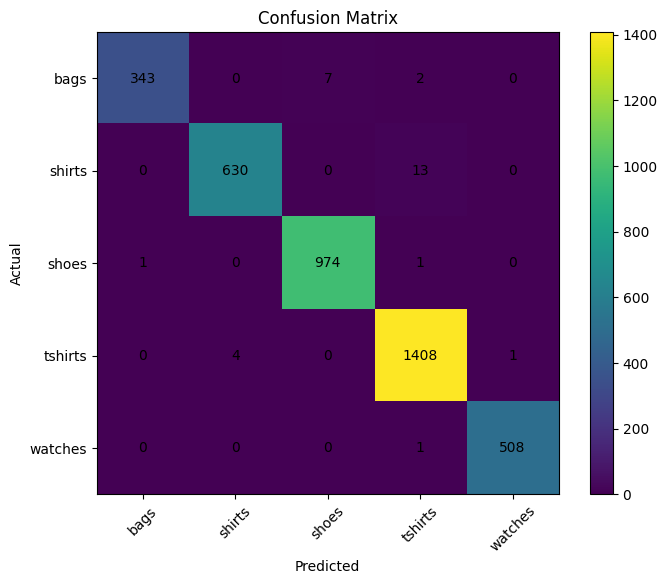

In [42]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

classes = ['bags', 'shirts', 'shoes', 'tshirts', 'watches']

plt.xticks(np.arange(len(classes)), classes, rotation=45)

plt.yticks(np.arange(len(classes)), classes)

plt.xlabel("Predicted")

plt.ylabel("Actual")

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.show()